<a href="https://colab.research.google.com/github/7777kuldeep/Deep_Learning_lab/blob/main/DL_LAB_07.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Shape: (20640, 9)
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  Price  
0    -122.23  4.526  
1    -122.22  3.585  
2    -122.24  3.521  
3    -122.25  3.413  
4    -122.25  3.422  


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,521 (45.00 KB)

 Trainable params: 11,521 (45.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
929/929 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 1.0737 - mae: 0.6539 - val_loss: 0.4848 - val_mae: 0.4854
Epoch 2/100
929/929 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.3753 - mae: 0.4357 - val_loss: 0.3736 - val_mae: 0.4271
Epoch 3/100
929/929 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.3558 - mae: 0.4182 - val_loss: 0.3633 - val_mae: 0.4216
Epoch 4/100
929/929 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.3327 - mae: 0.3981 - val_loss: 0.3747 - val_mae: 0.4181
Epoch 5/100
929/929 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.3176 - mae: 0.3902 - val_loss: 0.3384 - val_mae: 0.4086
Epoch 6/100
929/929 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.2936 - mae: 0.3775 - val_loss: 0.3304 - val_mae: 0.3906
Epoch 7/100
929/929 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.3052 - mae: 0.3834 - val_loss: 0.3155 - val_mae: 0.3974
Epoch 8/100
929/929 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.2829 - mae: 0.3676 - val_loss: 0.3102 - val_mae: 0.3826
Epoch 9/100
929/929 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/

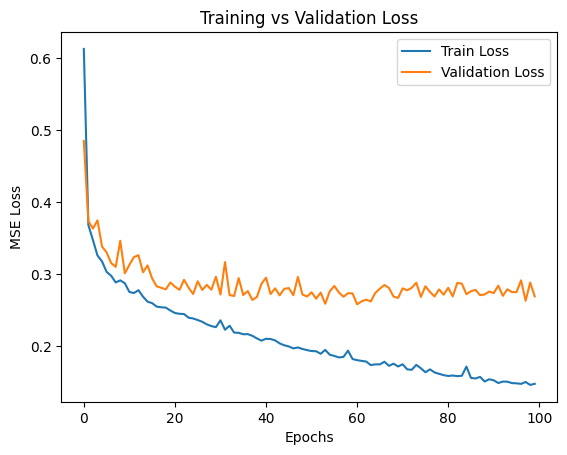

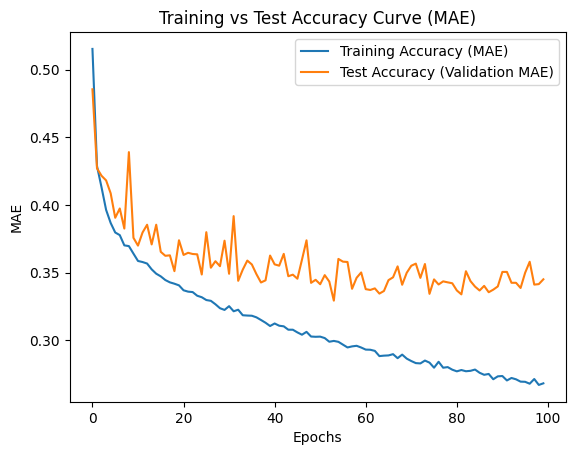

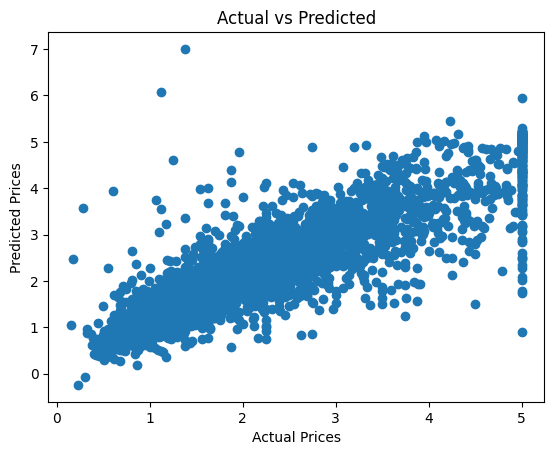

In [ ]:
# ==========================================
# 1. Import Libraries
# ==========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# ==========================================
# 2. Load Dataset
# ==========================================
housing = fetch_california_housing()

df = pd.DataFrame(housing.data, columns=housing.feature_names)
df["Price"] = housing.target

print("Dataset Shape:", df.shape)
print(df.head())

# ==========================================
# 3. Feature Target Split
# ==========================================
X = df.drop("Price", axis=1)
y = df["Price"]

# ==========================================
# 4. Train Test Split
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ==========================================
# 5. Feature Scaling
# ==========================================
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ==========================================
# 6. Build Model
# ==========================================
model = tf.keras.Sequential([

    tf.keras.layers.Dense(128,
    activation='relu',
    input_shape=(X_train.shape[1],)),

    tf.keras.layers.Dense(64,activation='relu'),

    tf.keras.layers.Dense(32,activation='relu'),

    tf.keras.layers.Dense(1)

])

model.compile(

optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),

loss='mse',

metrics=['mae']

)

model.summary()

# ==========================================
# 7. Train Model (Batch Size Changed)
# ==========================================

batch_size = 16   # Try 16 ,32 ,64 ,128

history = model.fit(

X_train,
y_train,

validation_split=0.1,

epochs=100,

batch_size=batch_size,

verbose=1

)

# ==========================================
# 8. Evaluate Model
# ==========================================

loss , mae = model.evaluate(X_test,y_test)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test,y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test,y_pred)

print("\nBatch Size:",batch_size)

print("Test MAE:",mae)

print("RMSE:",rmse)

print("R2 Score:",r2)

# ==========================================
# 9. Training vs Validation LOSS Curve
# ==========================================

plt.figure()

plt.plot(history.history['loss'],label='Train Loss')

plt.plot(history.history['val_loss'],label='Validation Loss')

plt.legend()

plt.title("Training vs Validation Loss")

plt.xlabel("Epochs")

plt.ylabel("MSE Loss")

plt.show()

# ==========================================
# 10. Training vs Validation MAE
# (Accuracy type curve)
# ==========================================

plt.figure()

plt.plot(history.history['mae'],label='Training Accuracy (MAE)')

plt.plot(history.history['val_mae'],label='Test Accuracy (Validation MAE)')

plt.legend()

plt.title("Training vs Test Accuracy Curve (MAE)")

plt.xlabel("Epochs")

plt.ylabel("MAE")

plt.show()

# ==========================================
# 11. Actual vs Predicted
# ==========================================

plt.figure()

plt.scatter(y_test,y_pred)

plt.xlabel("Actual Prices")

plt.ylabel("Predicted Prices")

plt.title("Actual vs Predicted")

plt.show()

Dataset Shape: (20640, 9)
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  Price  
0    -122.23  4.526  
1    -122.22  3.585  
2    -122.24  3.521  
3    -122.25  3.413  
4    -122.25  3.422  


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 128)            │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,521 (45.00 KB)

 Trainable params: 11,521 (45.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
465/465 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 1.1668 - mae: 0.7461 - val_loss: 0.4198 - val_mae: 0.4654
Epoch 2/100
465/465 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3704 - mae: 0.4329 - val_loss: 0.3953 - val_mae: 0.4369
Epoch 3/100
465/465 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3413 - mae: 0.4141 - val_loss: 0.3675 - val_mae: 0.4103
Epoch 4/100
465/465 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3269 - mae: 0.4009 - val_loss: 0.3538 - val_mae: 0.4162
Epoch 5/100
465/465 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3086 - mae: 0.3870 - val_loss: 0.3611 - val_mae: 0.4201
Epoch 6/100
465/465 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3034 - mae: 0.3854 - val_loss: 0.3399 - val_mae: 0.3978
Epoch 7/100
465/465 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3161 - mae: 0.3875 - val_loss: 0.3342 - val_mae: 0.3973
Epoch 8/100
465/465 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3064 - mae: 0.3823 - val_loss: 0.3151 - val_mae: 0.3843
Epoch 9/100
465/465 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/

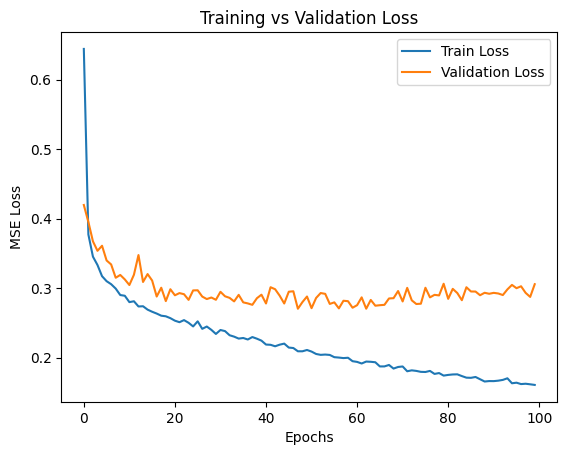

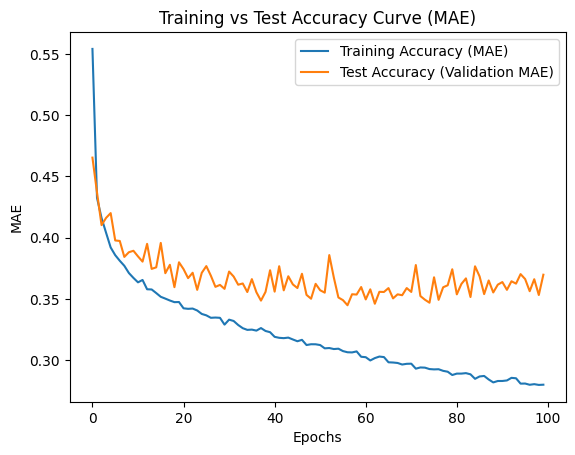

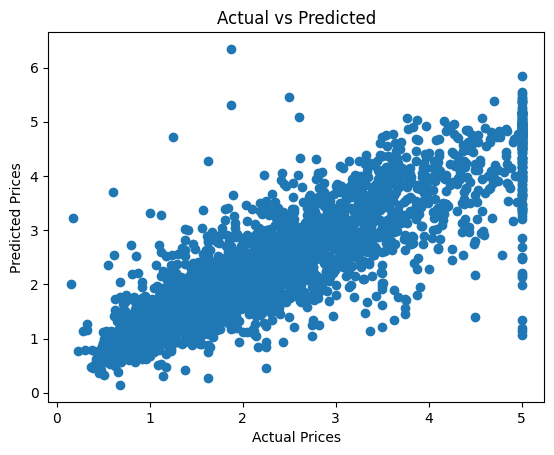

In [ ]:
# ==========================================
# 1. Import Libraries
# ==========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# ==========================================
# 2. Load Dataset
# ==========================================
housing = fetch_california_housing()

df = pd.DataFrame(housing.data, columns=housing.feature_names)
df["Price"] = housing.target

print("Dataset Shape:", df.shape)
print(df.head())

# ==========================================
# 3. Feature Target Split
# ==========================================
X = df.drop("Price", axis=1)
y = df["Price"]

# ==========================================
# 4. Train Test Split
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ==========================================
# 5. Feature Scaling
# ==========================================
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ==========================================
# 6. Build Model
# ==========================================
model = tf.keras.Sequential([

    tf.keras.layers.Dense(128,
    activation='relu',
    input_shape=(X_train.shape[1],)),

    tf.keras.layers.Dense(64,activation='relu'),

    tf.keras.layers.Dense(32,activation='relu'),

    tf.keras.layers.Dense(1)

])

model.compile(

optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),

loss='mse',

metrics=['mae']

)

model.summary()

# ==========================================
# 7. Train Model (Batch Size Changed)
# ==========================================

batch_size = 32   # Try 16 ,32 ,64 ,128

history = model.fit(

X_train,
y_train,

validation_split=0.1,

epochs=100,

batch_size=batch_size,

verbose=1

)

# ==========================================
# 8. Evaluate Model
# ==========================================

loss , mae = model.evaluate(X_test,y_test)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test,y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test,y_pred)

print("\nBatch Size:",batch_size)

print("Test MAE:",mae)

print("RMSE:",rmse)

print("R2 Score:",r2)

# ==========================================
# 9. Training vs Validation LOSS Curve
# ==========================================

plt.figure()

plt.plot(history.history['loss'],label='Train Loss')

plt.plot(history.history['val_loss'],label='Validation Loss')

plt.legend()

plt.title("Training vs Validation Loss")

plt.xlabel("Epochs")

plt.ylabel("MSE Loss")

plt.show()

# ==========================================
# 10. Training vs Validation MAE
# (Accuracy type curve)
# ==========================================

plt.figure()

plt.plot(history.history['mae'],label='Training Accuracy (MAE)')

plt.plot(history.history['val_mae'],label='Test Accuracy (Validation MAE)')

plt.legend()

plt.title("Training vs Test Accuracy Curve (MAE)")

plt.xlabel("Epochs")

plt.ylabel("MAE")

plt.show()

# ==========================================
# 11. Actual vs Predicted
# ==========================================

plt.figure()

plt.scatter(y_test,y_pred)

plt.xlabel("Actual Prices")

plt.ylabel("Predicted Prices")

plt.title("Actual vs Predicted")

plt.show()

Dataset Shape: (20640, 9)
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  Price  
0    -122.23  4.526  
1    -122.22  3.585  
2    -122.24  3.521  
3    -122.25  3.413  
4    -122.25  3.422  


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 128)            │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,521 (45.00 KB)

 Trainable params: 11,521 (45.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
233/233 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 1.7682 - mae: 0.9074 - val_loss: 0.4405 - val_mae: 0.4820
Epoch 2/100
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3784 - mae: 0.4399 - val_loss: 0.4010 - val_mae: 0.4502
Epoch 3/100
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3480 - mae: 0.4193 - val_loss: 0.4234 - val_mae: 0.4863
Epoch 4/100
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3538 - mae: 0.4227 - val_loss: 0.3701 - val_mae: 0.4301
Epoch 5/100
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3182 - mae: 0.3946 - val_loss: 0.3545 - val_mae: 0.4238
Epoch 6/100
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3285 - mae: 0.4017 - val_loss: 0.3525 - val_mae: 0.4066
Epoch 7/100
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3019 - mae: 0.3853 - val_loss: 0.3426 - val_mae: 0.4037
Epoch 8/100
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3068 - mae: 0.3852 - val_loss: 0.3286 - val_mae: 0.4051
Epoch 9/100
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/

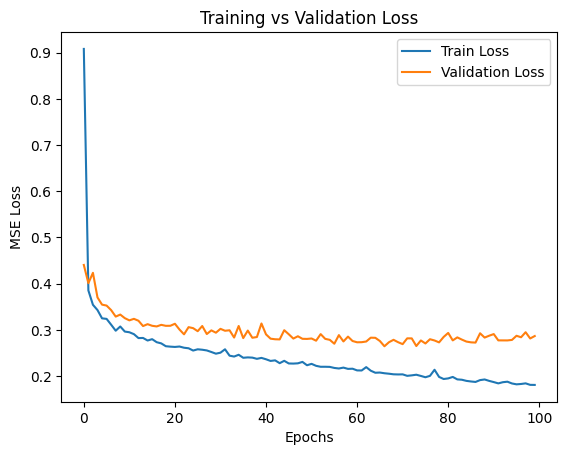

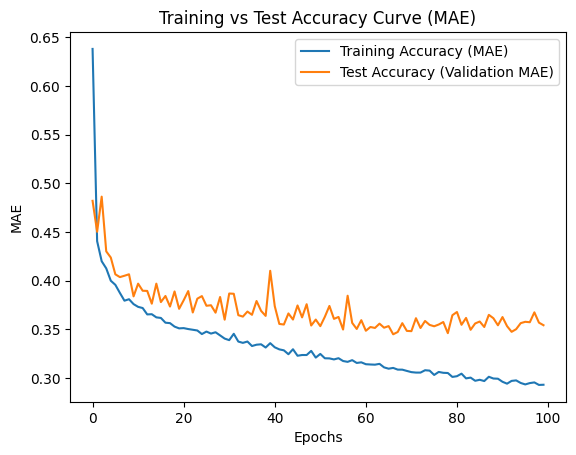

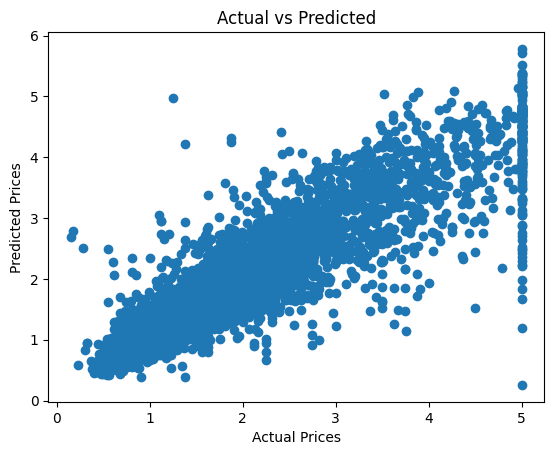

In [ ]:
# ==========================================
# 1. Import Libraries
# ==========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# ==========================================
# 2. Load Dataset
# ==========================================
housing = fetch_california_housing()

df = pd.DataFrame(housing.data, columns=housing.feature_names)
df["Price"] = housing.target

print("Dataset Shape:", df.shape)
print(df.head())

# ==========================================
# 3. Feature Target Split
# ==========================================
X = df.drop("Price", axis=1)
y = df["Price"]

# ==========================================
# 4. Train Test Split
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ==========================================
# 5. Feature Scaling
# ==========================================
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ==========================================
# 6. Build Model
# ==========================================
model = tf.keras.Sequential([

    tf.keras.layers.Dense(128,
    activation='relu',
    input_shape=(X_train.shape[1],)),

    tf.keras.layers.Dense(64,activation='relu'),

    tf.keras.layers.Dense(32,activation='relu'),

    tf.keras.layers.Dense(1)

])

model.compile(

optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),

loss='mse',

metrics=['mae']

)

model.summary()

# ==========================================
# 7. Train Model (Batch Size Changed)
# ==========================================

batch_size = 64  # Try 16 ,32 ,64 ,128

history = model.fit(

X_train,
y_train,

validation_split=0.1,

epochs=100,

batch_size=batch_size,

verbose=1

)

# ==========================================
# 8. Evaluate Model
# ==========================================

loss , mae = model.evaluate(X_test,y_test)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test,y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test,y_pred)

print("\nBatch Size:",batch_size)

print("Test MAE:",mae)

print("RMSE:",rmse)

print("R2 Score:",r2)

# ==========================================
# 9. Training vs Validation LOSS Curve
# ==========================================

plt.figure()

plt.plot(history.history['loss'],label='Train Loss')

plt.plot(history.history['val_loss'],label='Validation Loss')

plt.legend()

plt.title("Training vs Validation Loss")

plt.xlabel("Epochs")

plt.ylabel("MSE Loss")

plt.show()

# ==========================================
# 10. Training vs Validation MAE
# (Accuracy type curve)
# ==========================================

plt.figure()

plt.plot(history.history['mae'],label='Training Accuracy (MAE)')

plt.plot(history.history['val_mae'],label='Test Accuracy (Validation MAE)')

plt.legend()

plt.title("Training vs Test Accuracy Curve (MAE)")

plt.xlabel("Epochs")

plt.ylabel("MAE")

plt.show()

# ==========================================
# 11. Actual vs Predicted
# ==========================================

plt.figure()

plt.scatter(y_test,y_pred)

plt.xlabel("Actual Prices")

plt.ylabel("Predicted Prices")

plt.title("Actual vs Predicted")

plt.show()